# Customer Feedback Analysis — Women's E-Commerce Reviews

The goal is to find critical customer reviews, understand common complaints,
and use Generative AI to draft responses for a few of the most important cases.

This follows the assessment requirements:
- clean the review data
- identify 1–2 star reviews using rule-based logic
- find common complaint keywords
- select 3 detailed critical reviews
- generate personalized response emails using GenAI


## 1 · Setup & imports

In [1]:
import os
import re
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)


## 2 · Load & first look

Load the file and get oriented: size, first rows, column types, and summaries.

In [3]:
CSV = r"C:\Users\Surbh\OneDrive\Desktop\Womens Clothing E-Commerce Reviews.csv"

df = pd.read_csv(CSV)
df_raw = df.copy()

print("Shape:", df.shape)


Shape: (23486, 11)


In [4]:
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comfortable,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length...",5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i co...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!,5,1,6,General,Tops,Blouses


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [6]:
df.describe(include="all")

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
count,23486.000000,23486.000000,23486.000000,19676,22641,23486.000000,23486.000000,23486.000000,23472,23472,23472
unique,NaN,NaN,NaN,13993,22634,NaN,NaN,NaN,3,6,20
top,NaN,NaN,NaN,Love it!,Perfect fit and i've gotten so many compliments. i buy all my suits from here now!,NaN,NaN,NaN,General,Tops,Dresses
freq,NaN,NaN,NaN,136,3,NaN,NaN,NaN,13850,10468,6319
mean,11742.500000,918.118709,43.198544,NaN,NaN,4.196032,0.822362,2.535936,NaN,NaN,NaN
std,6779.968547,203.298980,12.279544,NaN,NaN,1.110031,0.382216,5.702202,NaN,NaN,NaN
min,0.000000,0.000000,18.000000,NaN,NaN,1.000000,0.000000,0.000000,NaN,NaN,NaN
25%,5871.250000,861.000000,34.000000,NaN,NaN,4.000000,1.000000,0.000000,NaN,NaN,NaN
50%,11742.500000,936.000000,41.000000,NaN,NaN,5.000000,1.000000,1.000000,NaN,NaN,NaN
75%,17613.750000,1078.000000,52.000000,NaN,NaN,5.000000,1.000000,3.000000,NaN,NaN,NaN


## 3 · Data quality audit

Check missing values, duplicates and the rating range before changing anything.

In [7]:
def quality_report(data):
    report = pd.DataFrame({
        "dtype": data.dtypes,
        "nulls": data.isna().sum(),
        "null_pct": (data.isna().mean() * 100).round(1),
        "unique": data.nunique(),
    })
    return report

quality_report(df)


,dtype,nulls,null_pct,unique
Unnamed: 0,int64,0,0.0,23486
Clothing ID,int64,0,0.0,1206
Age,int64,0,0.0,77
Title,object,3810,16.2,13993
Review Text,object,845,3.6,22634
Rating,int64,0,0.0,5
Recommended IND,int64,0,0.0,2
Positive Feedback Count,int64,0,0.0,82
Division Name,object,14,0.1,3
Department Name,object,14,0.1,6


In [8]:
print("Duplicate rows:", df.duplicated().sum())
print("Minimum rating:", df["Rating"].min())
print("Maximum rating:", df["Rating"].max())


Duplicate rows: 0
Minimum rating: 1
Maximum rating: 5


## 4 · Inconsistencies

Fix simple issues that can affect the analysis:
- remove the exported index column
- clean spaces in text columns
- check duplicate rows
- keep the original review text unchanged

In [9]:
# The first column is just an exported dataframe index
if "Unnamed: 0" in df.columns:
    df = df.drop(columns="Unnamed: 0")

text_cols = df.select_dtypes(include="object").columns

for col in text_cols:
    df[col] = df[col].str.strip()

print("Duplicates before:", df.duplicated().sum())


Duplicates before: 21


In [10]:
df = df.drop_duplicates().copy()
print("Duplicates after:", df.duplicated().sum())


Duplicates after: 0


## 5 · Missing values

`Review Text` is the important field for this project. Rows without review text
cannot be used for complaint analysis or AI response generation.

A missing review title is less important, so those rows can stay.

In [11]:
df.isna().sum().sort_values(ascending=False)


Title                      3789
Review Text                 825
Division Name                14
Department Name              14
Class Name                   14
Clothing ID                   0
Age                           0
Rating                        0
Recommended IND               0
Positive Feedback Count       0
dtype: int64

In [12]:
review_df = df.dropna(subset=["Review Text"]).copy()

print("Original rows:", len(df))
print("Rows with review text:", len(review_df))
print("Rows without review text:", len(df) - len(review_df))


Original rows: 23465
Rows with review text: 22640
Rows without review text: 825


## 6 · Text cleaning

Create a cleaned version of the review instead of changing the original.

Steps:
- lowercase
- remove HTML tags
- remove special characters
- remove extra spaces

I am not removing words like `not` because they can change the meaning of a complaint.

In [13]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

review_df["Clean Review"] = review_df["Review Text"].apply(clean_text)
review_df["Review Word Count"] = review_df["Clean Review"].str.split().str.len()

review_df[["Review Text", "Clean Review"]].head()


,Review Text,Clean Review
0,Absolutely wonderful - silky and sexy and comfortable,absolutely wonderful silky and sexy and comfortable
1,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length...",love this dress it s sooo pretty i happened to find it in a store and i m glad i did bc i never would have ordered it online bc it s petite i bought a petite and am i love the length on me hits ju...
2,I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i co...,i had such high hopes for this dress and really wanted it to work for me i initially ordered the petite small my usual size but i found this to be outrageously small so small in fact that i could ...
3,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",i love love love this jumpsuit it s fun flirty and fabulous every time i wear it i get nothing but great compliments
4,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!,this shirt is very flattering to all due to the adjustable front tie it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan love this shirt


## 7 · Rating analysis

First look at how the ratings are distributed.

For this assessment, 1- and 2-star reviews will be treated as **critical**.

In [14]:
rating_counts = review_df["Rating"].value_counts().sort_index()
rating_counts


Rating
1      821
2     1549
3     2823
4     4908
5    12539
Name: count, dtype: int64

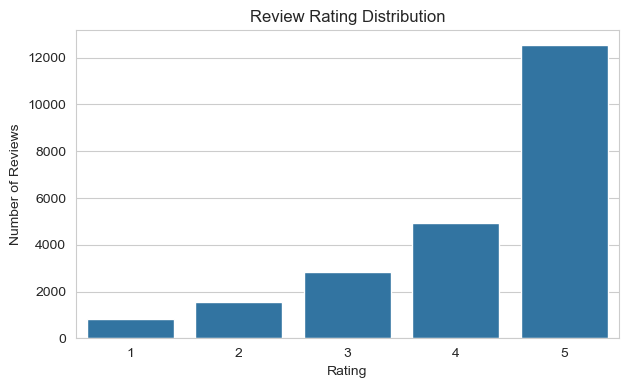

In [15]:
plt.figure(figsize=(7, 4))
sns.countplot(data=review_df, x="Rating")
plt.title("Review Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()


## 8 · Critical reviews

Use the simple rule from the assessment:

`Rating <= 2` → Critical

In [16]:
critical_reviews = review_df[review_df["Rating"] <= 2].copy()

critical_count = len(critical_reviews)
critical_pct = critical_count / len(review_df) * 100

print("Critical reviews:", critical_count)
print("Critical review percentage:", round(critical_pct, 2), "%")


Critical reviews: 2370
Critical review percentage: 10.47 %


In [17]:
critical_reviews[["Rating", "Title", "Review Text"]].head(10)


,Rating,Title,Review Text
5,2,Not for the very petite,"I love tracy reese dresses, but this one is not for the very petite. i am just under 5 feet tall and usually wear a 0p in this brand. this dress was very pretty out of the package but its a lot of..."
22,2,Not what it looks like,"First of all, this is not pullover styling. there is a side zipper. i wouldn't have purchased it if i knew there was a side zipper because i have a large bust and side zippers are next to impossib..."
26,2,Huge disappointment,I have been waiting for this sweater coat to ship for weeks and i was so excited for it to arrive. this coat is not true to size and made me look short and squat. the sleeves are very wide (althou...
33,2,Mehh,"I ordered this 3 months ago, and it finally came off back order. a huge disappointment. the fit wasn&#39;t so much the issue for me. the quality of the wool is subpar. someone else mentioned a &qu..."
56,2,NaN,"I am pregnant and i thought this would be a great sleep bra. it's soft and fits okay, but it has zero support or shape. i would only buy if you are a b cup or smaller and can get away without supp..."
61,1,Itchy tags,"3 tags sewn in, 2 small (about 1'' long) and 1 huge (about 2'' x 3''). very itchy so i cut them out. then the thread left behind was plasticy and even more itchy! how can you make an intimates ite..."
68,2,I wanted to love this top...,"I really loved this top online and wanted to love it in person. it is soft and the patter is okay in person. the neckline is higher than i am used to. also, there are two buttons in the back that ..."
71,2,Short and boxy,"Why do designers keep making crop tops??!! i can't imagine this would be flattering on anyone, especially someone average height and well endowed on top. i looked like a football player. the patte..."
77,2,Zipper broke,"The zipper broke on this piece the first time i wore it. very disappointing since i love the design. i'm actually going to try to replace the zipper myself with something stronger, but annoying th..."
85,1,NaN,"I was really hoping to like this, but it did not look the way it does on the model, at least not on me. the sharkbite hem is much more pronounced and looser. the one in the photo looks like it was..."


## 9 · Common complaint keywords

Before deciding on complaint categories, look at the words that occur most often
in the critical reviews.

In [18]:
stop_words = set("""
the and was this that with for have had but not are were very from
they you your just its would could about really too all did does what
when then than out our their there into also only more some one my
i it a an to of in is on as be me we so do if or at by has been
""".split())

words = " ".join(critical_reviews["Clean Review"]).split()

words = [
    word for word in words
    if word not in stop_words and len(word) > 2
]

word_counts = Counter(words)

top_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["Keyword", "Count"]
)

top_words


,Keyword,Count
0,dress,1123
1,like,1076
2,top,830
3,fabric,712
4,fit,687
5,size,677
6,back,615
7,small,518
8,look,516
9,ordered,512


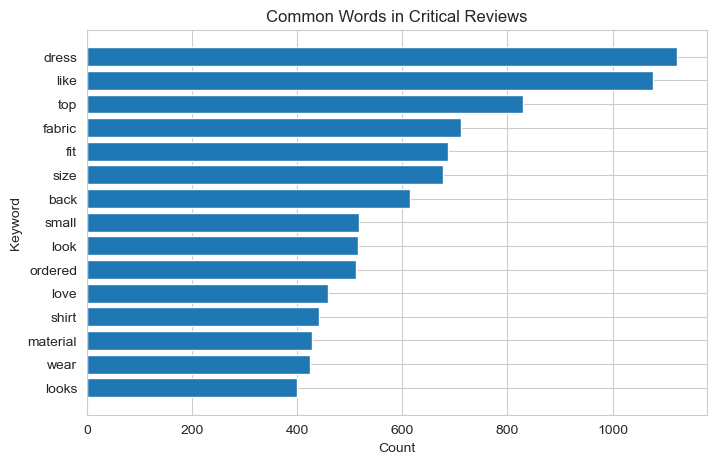

In [19]:
plot_words = top_words.head(15).sort_values("Count")

plt.figure(figsize=(8, 5))
plt.barh(plot_words["Keyword"], plot_words["Count"])
plt.title("Common Words in Critical Reviews")
plt.xlabel("Count")
plt.ylabel("Keyword")
plt.show()


## 10 · Complaint categories

Group related words into a few simple categories.

This is rule-based keyword matching, not machine learning.
A review can match more than one category.

In [20]:
complaint_keywords = {
    "Fit & Size": [
        "size", "sizing", "fit", "tight", "loose",
        "small", "large", "length", "waist", "sleeve"
    ],
    "Quality": [
        "quality", "poor", "cheap", "defective",
        "damaged", "broken", "tear", "torn", "stitch"
    ],
    "Material & Fabric": [
        "fabric", "material", "thin", "thick",
        "scratchy", "itchy", "rough", "sheer"
    ],
    "Color & Appearance": [
        "color", "colour", "faded", "fade",
        "print", "photo", "pictured"
    ],
    "Return / Refund": [
        "return", "returned", "refund",
        "exchange", "money"
    ],
    "Delivery / Shipping": [
        "delivery", "delivered", "shipping",
        "shipped", "late", "delay", "arrived", "package"
    ],
    "Customer Service": [
        "support", "service", "rude", "representative", "help"
    ]
}

def find_categories(text):
    found = []
    for category, keywords in complaint_keywords.items():
        for keyword in keywords:
            if re.search(rf"\b{re.escape(keyword)}\b", text):
                found.append(category)
                break
    return found

critical_reviews["Complaint Categories"] = (
    critical_reviews["Clean Review"].apply(find_categories)
)

critical_reviews[["Rating", "Review Text", "Complaint Categories"]].head(10)


,Rating,Review Text,Complaint Categories
5,2,"I love tracy reese dresses, but this one is not for the very petite. i am just under 5 feet tall and usually wear a 0p in this brand. this dress was very pretty out of the package but its a lot of...","[Fit & Size, Color & Appearance, Return / Refund, Delivery / Shipping]"
22,2,"First of all, this is not pullover styling. there is a side zipper. i wouldn't have purchased it if i knew there was a side zipper because i have a large bust and side zippers are next to impossib...","[Fit & Size, Quality, Return / Refund]"
26,2,I have been waiting for this sweater coat to ship for weeks and i was so excited for it to arrive. this coat is not true to size and made me look short and squat. the sleeves are very wide (althou...,[Fit & Size]
33,2,"I ordered this 3 months ago, and it finally came off back order. a huge disappointment. the fit wasn&#39;t so much the issue for me. the quality of the wool is subpar. someone else mentioned a &qu...","[Fit & Size, Quality, Material & Fabric]"
56,2,"I am pregnant and i thought this would be a great sleep bra. it's soft and fits okay, but it has zero support or shape. i would only buy if you are a b cup or smaller and can get away without supp...","[Quality, Return / Refund, Customer Service]"
61,1,"3 tags sewn in, 2 small (about 1'' long) and 1 huge (about 2'' x 3''). very itchy so i cut them out. then the thread left behind was plasticy and even more itchy! how can you make an intimates ite...","[Fit & Size, Material & Fabric, Customer Service]"
68,2,"I really loved this top online and wanted to love it in person. it is soft and the patter is okay in person. the neckline is higher than i am used to. also, there are two buttons in the back that ...",[Return / Refund]
71,2,"Why do designers keep making crop tops??!! i can't imagine this would be flattering on anyone, especially someone average height and well endowed on top. i looked like a football player. the patte...","[Fit & Size, Material & Fabric]"
77,2,"The zipper broke on this piece the first time i wore it. very disappointing since i love the design. i'm actually going to try to replace the zipper myself with something stronger, but annoying th...",[]
85,1,"I was really hoping to like this, but it did not look the way it does on the model, at least not on me. the sharkbite hem is much more pronounced and looser. the one in the photo looks like it was...","[Fit & Size, Material & Fabric, Color & Appearance]"


In [21]:
category_counts = Counter()

for categories in critical_reviews["Complaint Categories"]:
    category_counts.update(categories)

category_df = (
    pd.DataFrame(
        category_counts.items(),
        columns=["Complaint Category", "Review Count"]
    )
    .sort_values("Review Count", ascending=False)
    .reset_index(drop=True)
)

category_df


,Complaint Category,Review Count
0,Fit & Size,1378
1,Material & Fabric,1070
2,Color & Appearance,537
3,Quality,477
4,Return / Refund,418
5,Delivery / Shipping,135
6,Customer Service,36


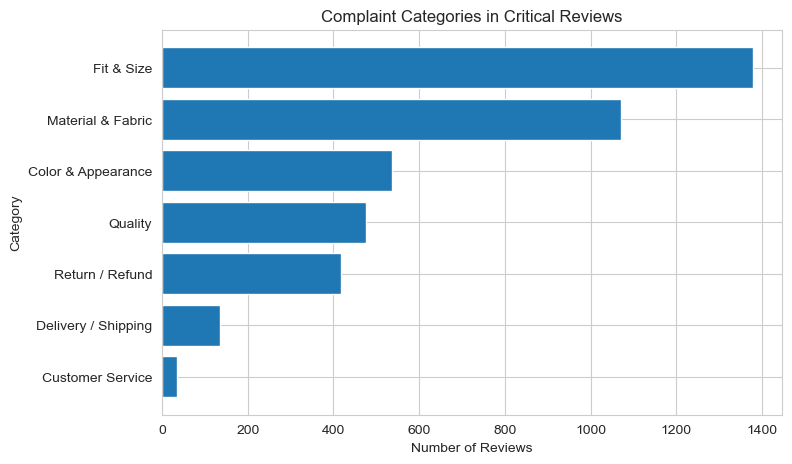

In [22]:
plt.figure(figsize=(8, 5))
plot_categories = category_df.sort_values("Review Count")

plt.barh(
    plot_categories["Complaint Category"],
    plot_categories["Review Count"]
)

plt.title("Complaint Categories in Critical Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Category")
plt.show()


## 11 · Select 3 detailed critical reviews

The assessment asks for 3 of the most critical, detailed negative reviews.

I will keep the scoring simple:
- 1 star → 3 points
- 2 stars → 2 points
- 40+ words → 1 point
- 80+ words → 2 points
- each complaint category → 1 point, up to 3 points

This gives us a transparent way to choose the three reviews.

In [23]:
def rating_points(rating):
    if rating == 1:
        return 3
    if rating == 2:
        return 2
    return 0

def detail_points(word_count):
    if word_count >= 80:
        return 2
    if word_count >= 40:
        return 1
    return 0

critical_reviews["Rating Points"] = critical_reviews["Rating"].apply(rating_points)
critical_reviews["Detail Points"] = critical_reviews["Review Word Count"].apply(detail_points)
critical_reviews["Category Points"] = critical_reviews["Complaint Categories"].str.len().clip(upper=3)

critical_reviews["Priority Score"] = (
    critical_reviews["Rating Points"]
    + critical_reviews["Detail Points"]
    + critical_reviews["Category Points"]
)

top_3 = (
    critical_reviews
    .sort_values(
        ["Priority Score", "Review Word Count"],
        ascending=[False, False]
    )
    .head(3)
    .copy()
)

top_3[
    [
        "Rating",
        "Review Word Count",
        "Complaint Categories",
        "Priority Score",
        "Review Text"
    ]
]


,Rating,Review Word Count,Complaint Categories,Priority Score,Review Text
6697,1,113,"[Fit & Size, Material & Fabric, Color & Appearance]",8,"I wanted to love this blouse so much. but try as i might, it just fit so oddly on me. i'm usually a petite s so i purchased the xs in brown. first. the color was more gray-brown but it was still o..."
17459,1,106,"[Fit & Size, Color & Appearance, Customer Service]",8,I tried on an xs and it was boxy/roomy in the torso and the pocket on the wrist/forearm area made my arm look too bulky when i rolled the sleeves up like the model pictured. i love the idea of a r...
18276,1,106,"[Fit & Size, Return / Refund, Delivery / Shipping]",8,"I loved the look of this blouse online. i really wanted a cute eyelet top for summer. the blouse looked great out of the package but the fit was not good. i am a 00p and 32 b bra size, this top wa..."


## 12 · Generative AI

Now use Gemini to draft a response for each of the three reviews.

The prompt is kept simple: understand the complaint, apologize appropriately,
and do not invent refunds or other actions.

In [ ]:
# If needed, install once:
# %pip install -q google-genai


In [24]:
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

if GEMINI_API_KEY:
    from google import genai
    client = genai.Client(api_key=GEMINI_API_KEY)
    print("Gemini is ready.")
else:
    client = None
    print("Gemini API key not found.")
    print("Set GEMINI_API_KEY before running the response-generation cell.")


Gemini API key not found.
Set GEMINI_API_KEY before running the response-generation cell.


In [ ]:
def make_prompt(review, rating, categories):
    category_text = ", ".join(categories) if categories else "general concern"

    return f"""
You are a customer support agent for an online clothing store.

Write a short and polite apology email based on this customer review.

Rating: {rating}/5
Complaint category: {category_text}

Customer review:
{review}

Please:
- acknowledge the specific problem
- sound empathetic and professional
- keep it around 80-120 words
- do not blame the customer
- do not invent a refund, replacement, discount or company policy
- do not claim that an action has already been taken

Return only the email.
"""


In [ ]:
def generate_response(review, rating, categories):
    prompt = make_prompt(review, rating, categories)

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )

    return response.text.strip()


In [ ]:
if client is not None:
    top_3["AI Response"] = [
        generate_response(
            row["Review Text"],
            row["Rating"],
            row["Complaint Categories"]
        )
        for _, row in top_3.iterrows()
    ]

    for i, (_, row) in enumerate(top_3.iterrows(), start=1):
        print(f"\n--- Case {i} ---")
        print("Rating:", row["Rating"])
        print("Complaint:", ", ".join(row["Complaint Categories"]))
        print("\nReview:")
        print(row["Review Text"])
        print("\nAI Response:")
        print(row["AI Response"])


## 13 · Final observations

Write 3–5 short observations from the actual results above.

For example:
- what percentage of reviews were critical
- which complaint category appeared most often
- what kind of issues appeared in the three selected reviews
- whether the generated responses addressed the actual complaints

Do not treat these results as causal conclusions.

In [ ]:
print("Total reviews with text:", len(review_df))
print("Critical reviews:", len(critical_reviews))
print("Critical review %:", round(len(critical_reviews) / len(review_df) * 100, 2))

if len(category_df) > 0:
    print("Most common complaint category:", category_df.iloc[0]["Complaint Category"])


## 14 · Limitations

- Complaint categories depend on the keywords I defined.
- Some complaints may be written in a way that the rules do not catch.
- The project uses ratings as the critical-review rule rather than a machine-learning model.
- AI-generated responses should be reviewed before being sent to a customer.

### Future improvement

A future version could use labelled historical complaints to train a complaint
classification model and could connect the output to a support-ticket system.
